['tBodyAcc-Mean-1                ' 'tBodyAcc-Mean-2                '
 'tBodyAcc-Mean-3                ' 'tBodyAcc-STD-1                 '
 'tBodyAcc-STD-2                 ' 'tBodyAcc-STD-3                 '
 'tBodyAcc-Mad-1                 ' 'tBodyAcc-Mad-2                 '
 'tBodyAcc-Mad-3                 ' 'tBodyAcc-Max-1                 ']
Training data shape: (7767, 561)
Test data shape: (3162, 561)
Unique activities in training set: ['STANDING' 'STAND_TO_SIT' 'SITTING' 'SIT_TO_STAND' 'STAND_TO_LIE'
 'LAYING' 'LIE_TO_SIT' 'SIT_TO_LIE' 'LIE_TO_STAND' 'WALKING'
 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS']


C:\Users\lisiq\AppData\Local\Temp\ipykernel_17836\263461271.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  activity_labels = pd.read_csv("activity_labels.txt", delim_whitespace=True, header=None, index_col=0)[1]


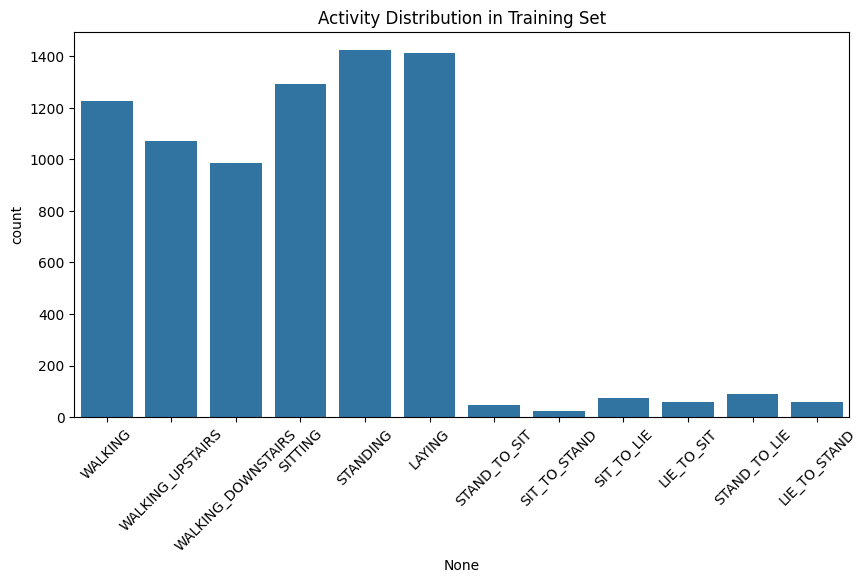

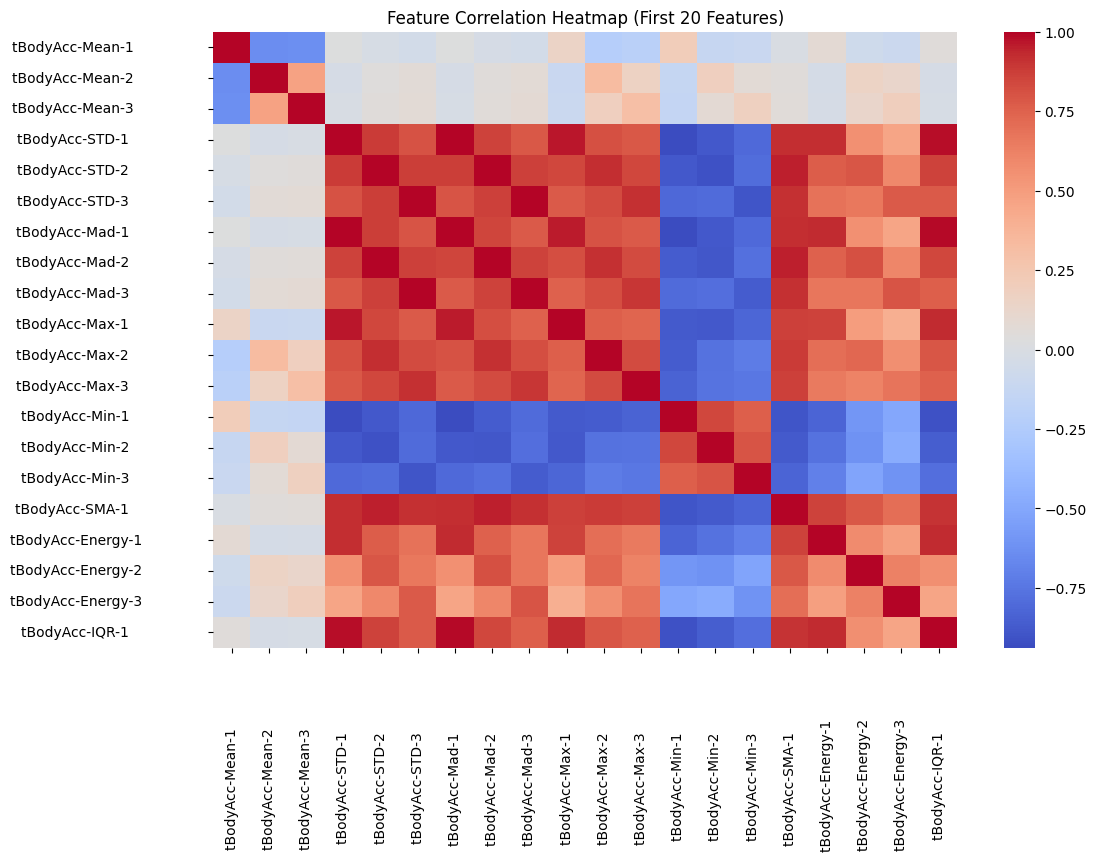

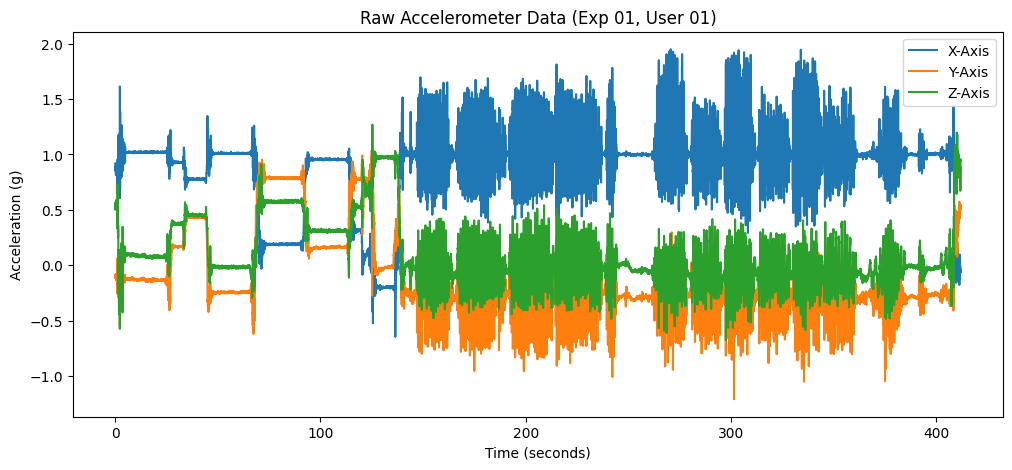

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature-based data
X_train = np.loadtxt("Train/X_train.txt")
y_train = np.loadtxt("Train/y_train.txt", dtype=int)
X_test = np.loadtxt("Test/X_test.txt")
y_test = np.loadtxt("Test/y_test.txt", dtype=int)

# Load subject data
subject_train = np.loadtxt("Train/subject_id_train.txt", dtype=int)
subject_test = np.loadtxt("Test/subject_id_test.txt", dtype=int)

# Load feature names
# Load feature names correctly
features = pd.read_csv("features.txt", header=None, names=["feature"]).values.flatten()

# Print first few feature names to verify
print(features[:10])  # Should display the first 10 feature names


# Convert to DataFrame for easier analysis
X_train_df = pd.DataFrame(X_train, columns=features)
X_test_df = pd.DataFrame(X_test, columns=features)

# Load activity labels
activity_labels = pd.read_csv("activity_labels.txt", delim_whitespace=True, header=None, index_col=0)[1]

# Convert labels to readable format
y_train_labels = pd.Series(y_train).map(activity_labels)
y_test_labels = pd.Series(y_test).map(activity_labels)

# Summary statistics
print("Training data shape:", X_train_df.shape)
print("Test data shape:", X_test_df.shape)
print("Unique activities in training set:", y_train_labels.unique())

# Plot activity distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_labels, order=activity_labels.values)
plt.xticks(rotation=45)
plt.title("Activity Distribution in Training Set")
plt.show()

# Correlation heatmap of first 20 features
plt.figure(figsize=(12, 8))
sns.heatmap(X_train_df.iloc[:, :20].corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (First 20 Features)")
plt.show()

# Sample raw data analysis
acc_sample = np.loadtxt("RawData/acc_exp01_user01.txt")
gyro_sample = np.loadtxt("RawData/gyro_exp01_user01.txt")

time_axis = np.arange(len(acc_sample)) / 50  # Convert sample index to seconds

plt.figure(figsize=(12, 5))
plt.plot(time_axis, acc_sample[:, 0], label="X-Axis")
plt.plot(time_axis, acc_sample[:, 1], label="Y-Axis")
plt.plot(time_axis, acc_sample[:, 2], label="Z-Axis")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Accelerometer Data (Exp 01, User 01)")
plt.legend()
plt.show()


Accuracy: 92.88%

Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.96      0.95       496
           2       0.89      0.92      0.91       471
           3       0.97      0.90      0.93       420
           4       0.93      0.89      0.91       508
           5       0.91      0.94      0.93       556
           6       1.00      1.00      1.00       545
           7       0.76      0.83      0.79        23
           8       0.77      1.00      0.87        10
           9       0.81      0.78      0.79        32
          10       0.68      0.60      0.64        25
          11       0.79      0.78      0.78        49
          12       0.64      0.67      0.65        27

    accuracy                           0.93      3162
   macro avg       0.84      0.86      0.85      3162
weighted avg       0.93      0.93      0.93      3162



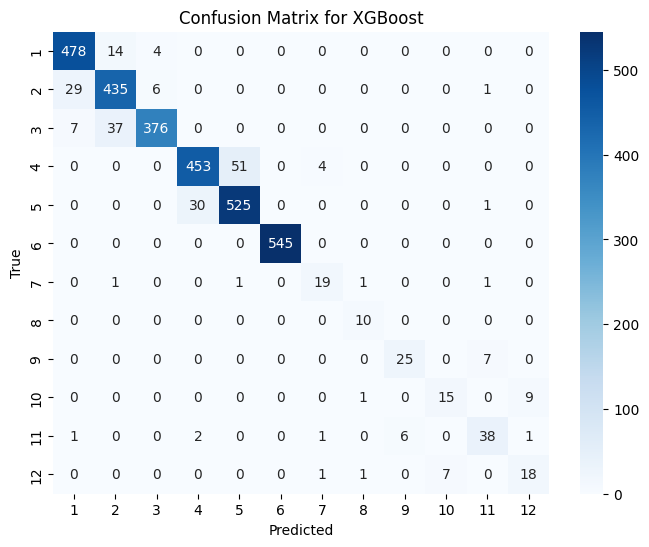

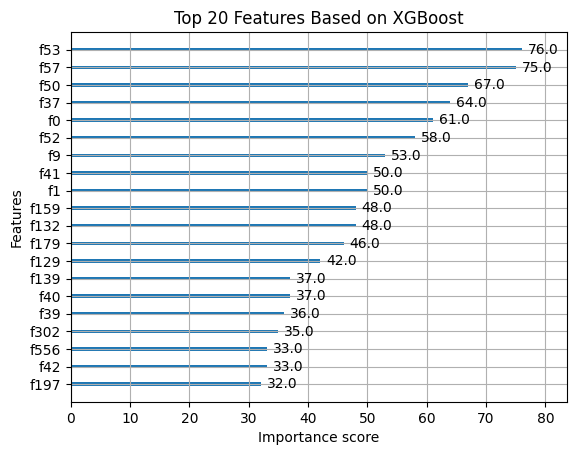


Per-Class Accuracy:
1: 96.37%
2: 92.36%
3: 89.52%
4: 89.17%
5: 94.42%
6: 100.00%
7: 82.61%
8: 100.00%
9: 78.12%
10: 60.00%
11: 77.55%
12: 66.67%


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Step 0: Ensure labels are properly encoded (0 to num_class-1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Step 1: Train an XGBoost Classifier
# Convert DataFrame to numpy array before creating DMatrix
X_train_array = X_train_df.values
X_test_array = X_test_df.values

# Create DMatrix
dtrain = xgb.DMatrix(X_train_array, label=y_train_encoded)
dtest = xgb.DMatrix(X_test_array, label=y_test_encoded)

# Define parameters for the classifier
params = {
    'objective': 'multi:softmax',
    'num_class': len(np.unique(y_train_encoded)),  # Use the encoded classes
    'eval_metric': 'mlogloss',
    'max_depth': 8,
    'eta': 0.3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
}

# Train the model
num_round = 100
bst = xgb.train(params, dtrain, num_round)

# Step 2: Predict using the test data
y_pred_encoded = bst.predict(dtest)
y_pred = le.inverse_transform(y_pred_encoded.astype(int))  # Convert back to original labels

# Step 3: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Step 4: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 5: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for XGBoost')
plt.show()

# Step 6: Feature Importance
xgb.plot_importance(bst, importance_type='weight', max_num_features=20)
plt.title("Top 20 Features Based on XGBoost")
plt.show()

# Compute per-class accuracy
class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

# Print per-class accuracy
print("\nPer-Class Accuracy:")
for label, acc in zip(le.classes_, class_accuracy):
    print(f"{label}: {acc * 100:.2f}%")



In [6]:
y_train_pred = bst.predict(dtrain)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")

Train Accuracy: 100.00%
